Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2489 - loss: 2.1235 - val_accuracy: 0.4618 - val_loss: 1.9193
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6649 - loss: 1.6171 - val_accuracy: 0.8160 - val_loss: 1.3456
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8686 - loss: 1.0201 - val_accuracy: 0.8646 - val_loss: 0.8077
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9086 - loss: 0.5959 - val_accuracy: 0.8646 - val_loss: 0.5155
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9278 - loss: 0.4001 - val_accuracy: 0.8854 - val_loss: 0.3977
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9460 - loss: 0.3033 - val_accuracy: 0.9062 - val_loss: 0.3305
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9513 - loss: 0.2502 - val_accuracy: 0.9201 - val_loss: 0.3092
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9495 - loss: 0.2180 - val_accuracy: 0.9306 - val_loss

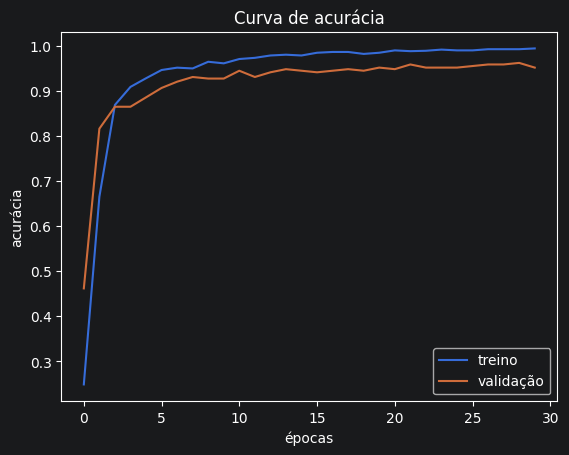

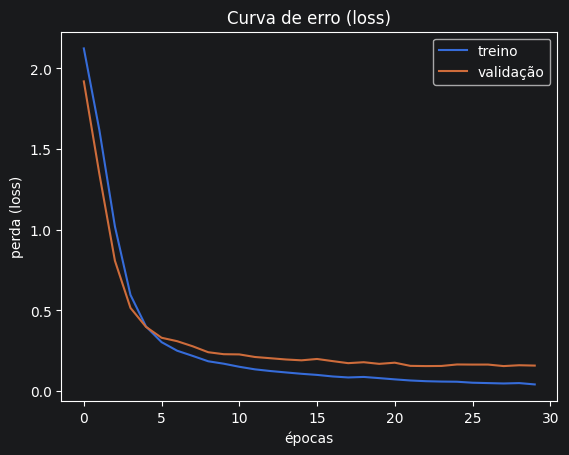

In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from tensorflow import keras
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

dados = load_digits()
x = dados.data / 16.0
y = dados.target

x_treino, x_test, y_treino, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

modelo = keras.Sequential([
    keras.layers.Input(shape=(64,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historico = modelo.fit(
    x_treino, y_treino,
    epochs=30, batch_size=32,
    validation_split=0.2
)

# Gráfico 1: acurácia (treino vs validação)
plt.figure()
plt.plot(historico.history['accuracy'], label='treino')
plt.plot(historico.history['val_accuracy'], label='validação')
plt.xlabel('épocas'); plt.ylabel('acurácia'); plt.legend()
plt.title('Curva de acurácia')
plt.savefig('curvas_aprendizado.png')

# Gráfico 2: perda / erro (treino vs validação)
plt.figure()
plt.plot(historico.history['loss'], label='treino')
plt.plot(historico.history['val_loss'], label='validação')
plt.xlabel('épocas'); plt.ylabel('perda (loss)'); plt.legend()
plt.title('Curva de erro (loss)')
plt.savefig('curvas_erro.png')

perda, acuracia = modelo.evaluate(x_test, y_test, verbose=0)
print("Acuracia no teste: ", round(acuracia, 3))
print("Perda no teste: ", round(perda, 3))